In [2]:
"""
Constructs the (unitary) DFT of the dihedral group in SageMath using knowledge of the representation theory.

""";

In [3]:
# ── Configuration ──────────────────────────────────────────────────────────────
n = 3; print("n =", n)
G = DihedralGroup(n); print("G =", G) #D_n, dihedral group of order 2n

USE_FINITE_FIELD = True
if USE_FINITE_FIELD:
    p = 13; print("p =", p) # characteristic of the finite field
    q = 13; print("q =", q) # size of the finite field

n = 3
G = Dihedral group of order 6 as a permutation group
p = 13
q = 13


In [4]:
def nth_root_of_unity(n, q=None):
    # Build the coefficient ring and choose omega
    if USE_FINITE_FIELD:
        # Find the smallest k such that n | (q^k - 1),
        # i.e. the multiplicative order of q mod n.
        k = Zmod(n)(q).multiplicative_order()
        F = GF(q**k, 'a')

        # Find a primitive n-th root of unity in F.
        # The multiplicative group of GF(q^k) is cyclic of order q^k - 1,
        # so a generator g satisfies g^((q^k-1)/n) has order n.
        g = F.multiplicative_generator()
        omega = g**((q**k - 1) // n)
        assert omega**n == F.one(), "omega is not an n-th root of unity"
        assert omega**(n-1) != F.one() or n == 1, "omega is not primitive"
        return (omega,F)
    else:
        K.<z> = CyclotomicField(n) #cyclotomic field containing a primitive n-th root of unity
        return (z, K)

In [5]:
# define generators for the dihedral group D_n
def G_gens(G, n):
    r = [g for g in G if g.order() == n][0] #rotation of order n, generator
    s = [g for g in G if g.order() == 2 and g != r**(n//2)][0] #flip of order 2, generator
    return r, s

In [6]:
# returns (0, k) if g = r^k and (1, k) if g = s*r^k
def express_in_gens(n, g, gens):
    r, s = gens
    for k in range(n):
        if g == r**k:
            return (0, k)
    for k in range(n):
        if g == s * r**k:
            return (1, k)

In [7]:
# n odd, we have two 1-dim'l irreps and (n-1)/2 2-dim'l irreps
# the 1-dim's irreps are trivial and sign
# the 2-dim'l irreps are given by rotation matrices and a flip matrix
def rho_odd(n, k, g, omega, gens):
    (s_exp, r_exp) = express_in_gens(n, g, gens)
    if k == 0:
        return matrix([1])
    if k == -1:
        if s_exp == 0:
            return matrix([1])
        if s_exp == 1:
            return matrix([-1])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(-k*r_exp)], [omega**(k*r_exp), 0]])

In [8]:
def dft_matrix_odd(n, omega, gens, G, unitary=False):
    assert n % 2 == 1
    dim = lambda k: 1 if k in (-1, 0) else 2
    rows = []
    for g in G:
        if unitary:
            if K.characteristic() > 0:
                R.<x> = K[]
                k.<a> = K.extension(x^2 - 2)
                L.<b> = k.extension(x^2 - n)
            else:
                L.<z> = CyclotomicField(4*n)
            row = [(sqrt(L(dim(k)/(2*n)))*rho_odd(n, k, g, omega, gens).change_ring(L)).list() for k in range(-1,(n-1)//2 + 1)]
        else:
            row = [rho_odd(n, k, g, omega, gens).transpose().list() for k in range(-1,(n-1)//2 + 1)]
        rows.append(sum(row, []))
    return matrix(rows)

In [9]:
# for n even case
def rho_even(n, k, g, omega, gens):
    (s_exp, r_exp) = express_in_gens(n, g, gens)
    if k == 0:   # trivial
        return matrix([1])
    if k == -1:  # sign of rotation
        return matrix([(-1)**r_exp])
    if k == -2:  # sign of reflection
        return matrix([(-1)**s_exp])
    if k == -3:  # total sign
        return matrix([(-1)**(r_exp + s_exp)])
    if k >= 1:
        if s_exp == 0:
            return matrix([[omega**(k*r_exp), 0], [0, omega**(-k*r_exp)]])
        if s_exp == 1:
            return matrix([[0, omega**(-k*r_exp)], [omega**(k*r_exp), 0]])

In [10]:
# form the DFT matrix for n even
def dft_matrix_even(n, omega, gens, G, unitary=False):
    assert n % 2 == 0
    rows = []
    for g in G:
        row = [rho_even(n, k, g, omega, gens).list() for k in range(-3, n//2)]
        rows.append(sum(row, []))
    return matrix(rows)

In [11]:
# compute the trace of the DFT matrix using the formula for the entries
def matrix_entries(i, j):
    if j == 0:
        return 1 if i < n else -1
    if j == 1:
        return 1

    k = j - 2
    m = k // 4 + 1
    r = k % 4

    if i < n:
        return omega**(m * i) if r == 0 else omega**(-m * i) if r == 3 else 0
    else:
        return omega**(m * i) if r == 1 else omega**(-m * i) if r == 2 else 0

In [12]:
# compute the trace of the DFT matrix using the formula for the entries
def trace_dft():
    total = 2
    total += sum(omega**(((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 2)
    total += sum(omega**(-((i-2)//4+1)*i) for i in range(2, n) if i % 4 == 1)
    total += sum(omega**(((i-2)//4+1)*i) for i in range(n, 2*n) if i % 4 == 3)
    total += sum(omega**(-(((i-2)//4+1)*i)) for i in range(n, 2*n) if i % 4 == 0)
    return total

In [13]:
def DFT_matrix_odd_from_entries():
    assert n % 2 == 1
    return matrix(2*n, 2*n, matrix_entries)

In [14]:
if not USE_FINITE_FIELD:
    omega, K = nth_root_of_unity(n)
    gens = G_gens(G, n)
    if n % 2 == 1:
        uDFT = dft_matrix_odd(n, omega, gens, G, unitary=True); print(uDFT.conjugate_transpose()*uDFT)
        DFT = dft_matrix_odd(n, omega, gens, G, unitary=False)
    if n% 2 == 0:
        uDFT = dft_matrix_even(n, omega, gens, G, unitary=True); print(uDFT.conjugate_transpose()*uDFT)
        DFT = dft_matrix_even(n, omega, gens, G, unitary=False)

In [15]:
if USE_FINITE_FIELD:
    omega, F = nth_root_of_unity(n, q); print(f"omega = {omega} in F = {F}")
    gens = G_gens(G, n); print(f"Generators: r = {gens[0]}, s = {gens[1]}")
    DFT_matrix = dft_matrix_odd(n, omega, gens, G) if n % 2 == 1 else dft_matrix_even(n, omega, gens, G); print(DFT_matrix)

omega = 3 in F = Finite Field of size 13
Generators: r = (1,3,2), s = (2,3)
[ 1  1  1  0  0  1]
[ 1  1  3  0  0  9]
[ 1  1  9  0  0  3]
[12  1  0  1  1  0]
[12  1  0  3  9  0]
[12  1  0  9  3  0]


In [16]:
from math import lcm

def charpoly_data(n, p):
    """
    Returns:
        base_deg: 1 or 2
        split_deg: degree of splitting field over base field
        factor_degs: sorted list of irreducible factor degrees (with multiplicity)
        factor_mults: list of (degree, multiplicity)
        lcm_deg: lcm of factor degrees
    """
    G = DihedralGroup(n)
    omega, F = nth_root_of_unity(n, p)
    gens = G_gens(G, n)

    if n % 2 == 1:
        M = dft_matrix_odd(n, omega, gens, G)
    else:
        M = dft_matrix_even(n, omega, gens, G)

    f = M.charpoly()

    # factorization over the base field F
    fac = f.factor()

    # collect degrees (with multiplicity)
    factor_degs = []
    factor_mults = []
    for g, m in fac:
        d = g.degree()
        factor_degs.extend([d] * m)
        factor_mults.append((d, m))

    factor_degs.sort()

    # lcm of degrees (Frobenius orbit lcm)
    lcm_deg = 1
    for d in factor_degs:
        lcm_deg = lcm(lcm_deg, d)

    # splitting field
    L = f.splitting_field('a')

    return F.degree(), L.degree(), factor_degs, factor_mults, lcm_deg

In [17]:
if USE_FINITE_FIELD:
    charpoly_data(7, 11)

In [18]:
import csv

def generate_table(n_values, p_values, filename="dft_dihedral_group_charpoly_data_finite_field.csv"):
    rows = []

    for n in sorted(n_values):
        for p in sorted(p_values):
            if (2*n) % p == 0:
                continue

            try:
                base_deg, split_deg, factor_degs, factor_mults, lcm_deg = charpoly_data(n, p)

                marker = "*" if base_deg != 1 else ""

                rows.append({
                    "n": n,
                    "p": p,
                    "base_deg": base_deg,
                    "split_deg": f"{split_deg}{marker}",
                    "lcm_deg": lcm_deg,
                    "factor_degs": str(factor_degs),
                    "factor_mults": str(factor_mults)
                })

            except Exception as e:
                rows.append({
                    "n": n,
                    "p": p,
                    "base_deg": "ERR",
                    "split_deg": str(e),
                    "lcm_deg": "",
                    "factor_degs": "",
                    "factor_mults": ""
                })

    with open(filename, "w", newline="") as csvfile:
        fieldnames = ["n", "p", "base_deg", "split_deg", "lcm_deg", "factor_degs", "factor_mults"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)

        writer.writeheader()
        for row in rows:
            writer.writerow(row)

    print(f"Table written to {filename}")

In [19]:
if USE_FINITE_FIELD:
    P = Primes(modulus=0, classes=range(500)).list()
    generate_table(n_values=range(3, 8), p_values=P)

Table written to dft_dihedral_group_charpoly_data_finite_field.csv


In [20]:
# the determinant is 2*n**n
if not USE_FINITE_FIELD:
    f = DFT.charpoly(); print(f)
else:
    f = DFT_matrix.charpoly(); print(f)

x^6 + 5*x^5 + 5*x^4 + 3*x^3 + 10*x^2 + x + 11


In [21]:
if USE_FINITE_FIELD:
    L.<a> = f.splitting_field(); print(L)

Finite Field in a of size 13^5


In [22]:
if USE_FINITE_FIELD:
    R_L.<x> = PolynomialRing(L)
    f_L = R_L(f)
    f_L.factor()

In [23]:
if USE_FINITE_FIELD:
    eigenvalues = f.roots(L, multiplicities=False)
    print(eigenvalues)
    print(len(eigenvalues))

[6, 10*a^2 + 9*a + 3, 9*a^4 + 5*a^3 + 8*a^2 + 11, 11*a^4 + 10*a^3 + 12*a^2 + 7, 5*a^4 + 5*a^3 + 9*a^2 + 2*a + 6, a^4 + 6*a^3 + 2*a + 1]
6


In [24]:
def frobenius(x, p):
    return x**p

In [25]:
def frobenius_orbit(alpha, p):
    orbit = []
    seen = set()
    
    x = alpha
    while x not in seen:
        seen.add(x)
        orbit.append(x)
        x = x**p
    
    return orbit

In [26]:
def frobenius_orbits(eigenvalues, p):
    orbits = []
    seen = set()
    
    for lam in eigenvalues:
        if lam not in seen:
            orb = frobenius_orbit(lam, p)
            orbits.append(orb)
            seen.update(orb)
    
    return orbits

In [27]:
def discrete_log_Fq(x, alpha=None):
    F = x.parent()
    if x == 0:
        raise ValueError("Log undefined for 0")
    if alpha is None:
        alpha = F.multiplicative_generator()
    return x.log(alpha)

In [28]:
if USE_FINITE_FIELD:
    frobenius_orbits(eigenvalues, p)

In [29]:
if USE_FINITE_FIELD:
    len(frobenius_orbit(eigenvalues[0], p))

In [30]:
if USE_FINITE_FIELD:
    dlogs = [discrete_log_Fq(x, alpha=None) for x in eigenvalues]; dlogs

In [31]:
def brauer_map(x):
    if x == 0:
        return 0
    else:
        l = discrete_log_Fq(x, alpha=None)
        return exp(2 * pi * I * l / (L.order()-1))

In [32]:
if USE_FINITE_FIELD:
    complex_eigs = [brauer_map(eig) for eig in eigenvalues]; complex_eigs
    eigs_num = [complex(e.n(digits=30)) for e in complex_eigs]; eigs_num

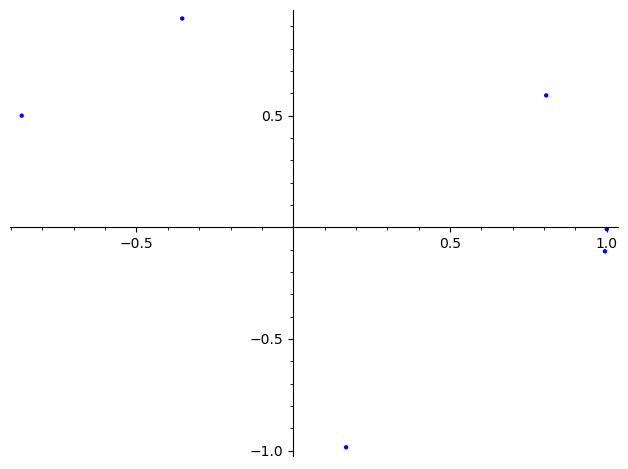

In [33]:
if USE_FINITE_FIELD:
    P = list_plot(
        [(z.real, z.imag) for z in eigs_num],
        plotjoined=False,
        marker='o'
    )

    P.show()

In [34]:
# form norm polynomial by acting on coefficients of characteristic polynomial by the Galois group
def norm_poly(f, n, z):

    def sigma(i):
        phi = K.hom([z**i])
        return f.map_coefficients(phi)
    
    units = [i for i in range(1, n) if gcd(i, n) == 1]  # (Z/nZ)^×
    result = prod(sigma(i) for i in units)
    return result.change_ring(QQ)

In [35]:
if not USE_FINITE_FIELD:
    Nf = norm_poly(f, n, omega); print("norm polynomial: ", Nf)
    print("norm polynomial irreducible:", Nf.is_irreducible())

In [36]:
if not USE_FINITE_FIELD:
    try:
        galois_group = Nf.galois_group()
    except NotImplementedError as e:
        print("Galois group computation not implemented:", e)

In [37]:
if not USE_FINITE_FIELD:
    galois_group = TransitiveGroup(12, 299)
    print(galois_group.order())
    print(galois_group.is_solvable())
    print(galois_group.is_primitive())
    print(galois_group.structure_description())

In [39]:
if not USE_FINITE_FIELD:
    modulus = 41
    cyc_poly = K.polynomial()
    cyc_poly_reduced = cyc_poly.change_ring(GF(modulus))
    print("cylotomic polynomial:", cyc_poly)
    print("cyclotomic polynomial reduced mod p:", cyc_poly_reduced)
    print("cyc_poly_reduced is irreducible:", cyc_poly_reduced.is_irreducible())
    print("cyc_poly_reduced factorization:", cyc_poly_reduced.factor())

    def reduce_and_factor(modulus, factor_poly):
        """Reduce f mod p using the prime ideal corresponding to factor_poly."""
        d = factor_poly.degree()
        F = GF(modulus^d, modulus=factor_poly, names='t')
        t = F.gen()
        
        def reduce_coeff(c):
            poly = c.polynomial()
            poly_mod = poly.change_ring(GF(modulus))
            return F(poly_mod(t))
        
        R_F = PolynomialRing(F, 'x')
        f_mod = R_F([reduce_coeff(c) for c in f.list()])
        return F, f_mod

    factors = [g for g, e in cyc_poly_reduced.factor()]

    for i, factor_poly in enumerate(factors):
        print(f"\n--- Prime ideal {i+1}, residue field defined by {factor_poly} ---")
        F, f_mod = reduce_and_factor(modulus, factor_poly)
        print(f"Residue field: {F}")
        print(f"f mod p: {f_mod}")
        print(f"Factorization: {f_mod.factor()}")

In [64]:
mult_orders = [la.multiplicative_order() for la in DFT_matrix.eigenvalues()]; print("multiplicative orders:", mult_orders)
DFT_order = LCM(mult_orders); print("order of DFT matrix:", DFT_order)

multiplicative orders: [12, 185646, 185646, 185646, 185646, 185646]
order of DFT matrix: 371292


In [63]:
fractional_DFT = DFT_matrix^(DFT_order/4); fractional_DFT

[ 2  2 10  2  6  2]
[11  2  2  3  9  3]
[ 6  4  6  4 12  4]
[11  3  2  2  9  3]
[ 8  1  5  1  2  1]
[11  3  2  3  9  2]